In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("../data/processed/preprocessed_reviews.csv")
df.head()


,review_id,review_text,sentiment_label,issue_label,is_multi_topic,secondary_issue,comment_type,processed_text
0,RV0001,bình nước nhìn ngoài được nhưng thực tế mùi rấ...,Negative,product_quality,no,NaN,normal,bình nước nhìn ngoài được nhưng thực tế mùi rấ...
1,RV0002,"giày dùng ổn, ship khá nhanh, bao bì sạch sẽ.",Positive,no_issue,no,NaN,normal,giày dùng ổn ship khá nhanh bao bì sạch sẽ
2,RV0003,"Giao khá nhanh nhưng giao sai màu, shop xử lý ...",Negative,wrong_item,yes,customer_service,mixed_topic,giao khá nhanh nhưng giao sai màu shop xử lý đ...
3,RV0004,"gói hàng nhìn rất cũ, may là bàn phím chưa hỏn...",Negative,packaging,no,NaN,normal,gói hàng nhìn rất cũ may là bàn phím chưa hỏng...
4,RV0005,Mình không hài lòng vì hộp bị móp khi nhận hàng.,Negative,packaging,no,NaN,normal,mình không hài lòng vì hộp bị móp khi nhận hàng


In [4]:
print("Shape:", df.shape)
print(df.columns.tolist())


Shape: (1092, 8)
['review_id', 'review_text', 'sentiment_label', 'issue_label', 'is_multi_topic', 'secondary_issue', 'comment_type', 'processed_text']


In [5]:
df.isna().sum()


review_id            0
review_text          0
sentiment_label      0
issue_label          0
is_multi_topic       0
secondary_issue    962
comment_type         0
processed_text       0
dtype: int64

In [6]:
df["sentiment_label"].value_counts()


sentiment_label
Negative    600
Positive    400
Neutral      92
Name: count, dtype: int64

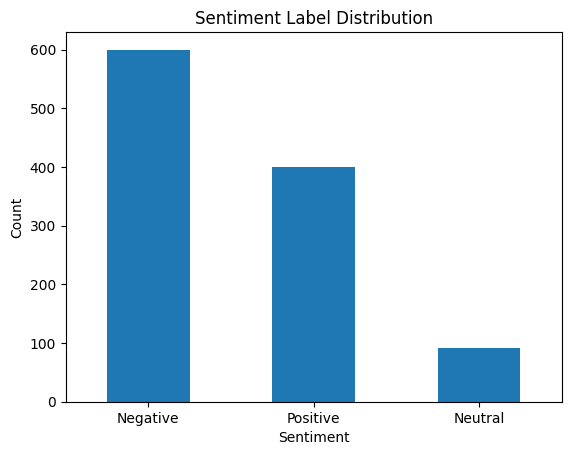

In [7]:
df["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


In [8]:
df["issue_label"].value_counts()


issue_label
no_issue              400
product_quality       150
delivery              120
wrong_item            100
packaging             100
spam_or_irrelevant     92
customer_service       80
price                  50
Name: count, dtype: int64

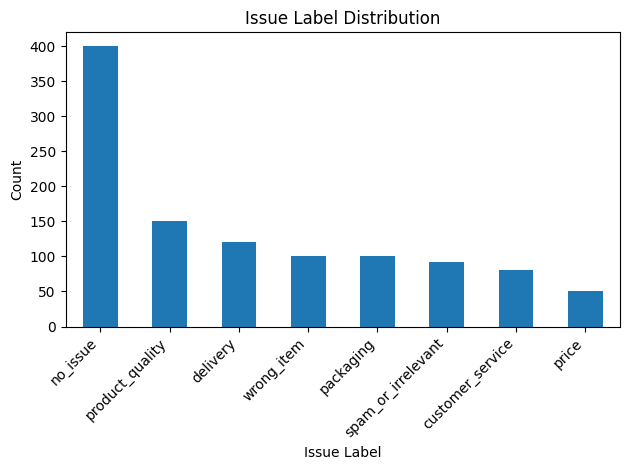

In [9]:
df["issue_label"].value_counts().plot(kind="bar")
plt.title("Issue Label Distribution")
plt.xlabel("Issue Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [10]:
df[["review_text", "processed_text", "sentiment_label", "issue_label"]].sample(10, random_state=42)


,review_text,processed_text,sentiment_label,issue_label
482,"Mình mua son, thấy dùng ổn, bên bán nhắn tin l...",mình mua son thấy dùng ổn bên bán nhắn tin lịc...,Positive,no_issue
139,"sạc dự phòng đẹp hơn mong đợi, nhận hàng sớm, ...",sạc dự phòng đẹp hơn mong đợi nhận hàng sớm gi...,Positive,no_issue
88,sạc dự phòng dùng ổn nhưng đợi rất lâu mới nhậ...,sạc dự phòng dùng ổn nhưng đợi rất lâu mới nhậ...,Negative,delivery
844,"đóng gói sơ sài, may là bình nước chưa hỏng hẳn.",đóng gói sơ sài may là bình nước chưa hỏng hẳn,Negative,packaging
730,Hàng không tệ nhưng trễ hẹn nhiều ngày nên mìn...,hàng không tệ nhưng trễ hẹn nhiều ngày nên mìn...,Negative,delivery
810,"Hàng chuẩn, hoạt động tốt, bên bán nhắn tin lị...",hàng chuẩn hoạt động tốt bên bán nhắn tin lịch...,Positive,no_issue
286,đồng hồ nhìn ngoài được nhưng thực tế chất lượ...,đồng hồ nhìn ngoài được nhưng thực tế chất lượ...,Negative,product_quality
440,"Đơn nồi chiên đợi rất lâu mới nhận được, hỏi t...",đơn nồi chiên đợi rất lâu mới nhận được hỏi th...,Negative,delivery
1086,"Gói hàng ổn, đóng đơn nhanh, sản phẩm chắc chắ...",gói hàng ổn đóng đơn nhanh sản phẩm chắc chắn ...,Positive,no_issue
823,"Đã dùng vài ngày, bình nước xài mượt, không có...",đã dùng vài ngày bình nước xài mượt không có l...,Positive,no_issue


In [11]:
df["word_count"] = df["processed_text"].str.split().str.len()
df["word_count"].describe()

count    1092.000000
mean       13.341575
std         3.158448
min         4.000000
25%        11.000000
50%        13.000000
75%        15.000000
max        24.000000
Name: word_count, dtype: float64

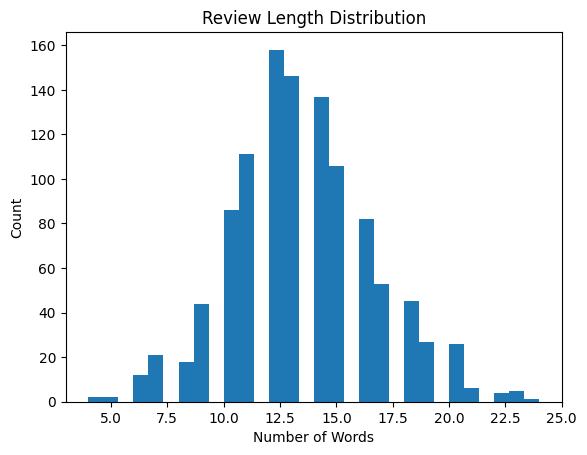

In [12]:
df["word_count"].plot(kind="hist", bins=30)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()
